# COM5001 CW1 Implementation Notebook  
## Bank Marketing Dataset — Predicting Term Deposit Subscription

**Business problem:** A bank wants to improve the efficiency of its direct marketing campaigns by predicting whether a customer is likely to subscribe to a term deposit.

**Research question:** Can machine learning models predict whether a bank customer will subscribe to a term deposit, and which customer/campaign factors are most useful for prediction?

**Dataset:** UCI Bank Marketing dataset. The target variable is `y`, where `yes` means the customer subscribed and `no` means the customer did not subscribe.

## Install and import libraries


In [2]:
# Install ucimlrepo if needed. This is useful in Google Colab.
try:
    import ucimlrepo
except ImportError:
    !pip -q install ucimlrepo

# Core libraries
import warnings
warnings.filterwarnings("ignore")

import io
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine learning libraries
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, RocCurveDisplay
)
import joblib

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

## Load the dataset from UCI


In [3]:
try:
    bank_marketing = fetch_ucirepo(id=222)
    X_raw = bank_marketing.data.features.copy()
    y_raw = bank_marketing.data.targets.copy()
    df = pd.concat([X_raw, y_raw], axis=1)
    print("Dataset loaded using ucimlrepo.")
except Exception as e:
    print("ucimlrepo loading failed. Trying direct UCI download...")
    print("Reason:", e)
    url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
    raw_zip = urllib.request.urlopen(url).read()
    with zipfile.ZipFile(io.BytesIO(raw_zip)) as z:
        csv_name = [name for name in z.namelist() if name.endswith("bank-full.csv")][0]
        df = pd.read_csv(z.open(csv_name), sep=";")
    print("Dataset loaded using direct UCI download.")

# Standardise target column name if needed
if "y" not in df.columns:
    possible_target = df.columns[-1]
    df = df.rename(columns={possible_target: "y"})

print("Shape:", df.shape)
df.head()

Dataset loaded using ucimlrepo.
Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


##  Initial data inspection
This shows column names, data types, duplicate rows, and the first few records.

In [4]:
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nNumber of duplicated rows:", df.duplicated().sum())

print("\nDataset sample:")
display(df.head())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data types:


age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
y              object
dtype: object


Number of duplicated rows: 0

Dataset sample:


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


## Target variable distribution
The target variable is imbalanced, so accuracy alone is not enough. We will also use precision, recall, F1-score, and ROC-AUC.

,count,percentage
y,,
no,39922,88.3
yes,5289,11.7


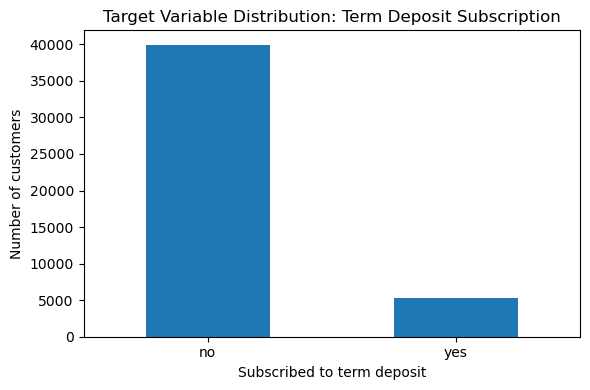

In [5]:
target_counts = df["y"].value_counts()
target_percent = df["y"].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent
})
display(target_summary)

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Target Variable Distribution: Term Deposit Subscription")
plt.xlabel("Subscribed to term deposit")
plt.ylabel("Number of customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Missing values and unknown categories
The UCI dataset has no formal missing values, but several categorical variables contain the value `unknown`. For modelling, we treat `unknown` as missing and impute it inside the preprocessing pipeline.

In [7]:
missing_values = df.isna().sum().sort_values(ascending=False)

print("Formal missing values:")
display(missing_values[missing_values > 0])

unknown_counts = {}

for col in df.select_dtypes(include="object").columns:
    unknown_counts[col] = (df[col] == "unknown").sum()

unknown_summary = pd.Series(unknown_counts).sort_values(ascending=False)

print("\n'unknown' category counts:")
display(unknown_summary[unknown_summary > 0])

Formal missing values:


poutcome     36959
contact      13020
education     1857
job            288
dtype: int64


'unknown' category counts:


Series([], dtype: int64)

##  Basic descriptive statistics
This helps identify ranges, possible outliers, and the structure of numerical variables.

In [8]:
print("Numerical summary:")
display(df.describe())

print("Categorical summary:")
display(df.describe(include="object"))

Numerical summary:


,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Categorical summary:


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,44923,45211,43354,45211,45211,45211,32191,45211,8252,45211
unique,11,3,3,2,2,2,2,12,3,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,failure,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,4901,39922


## Exploratory analysis: numerical variables
These histograms show the spread of the main numerical variables.

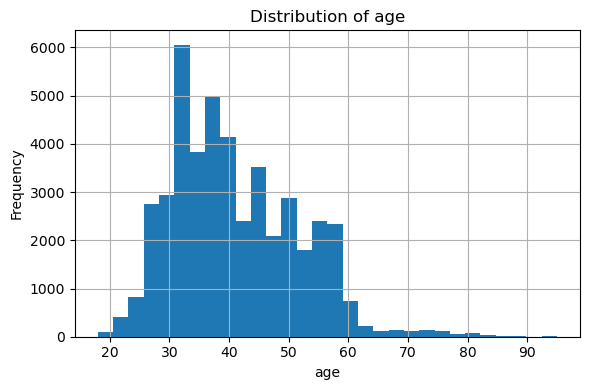

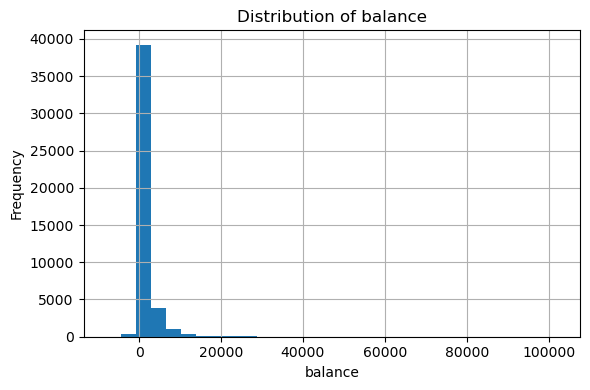

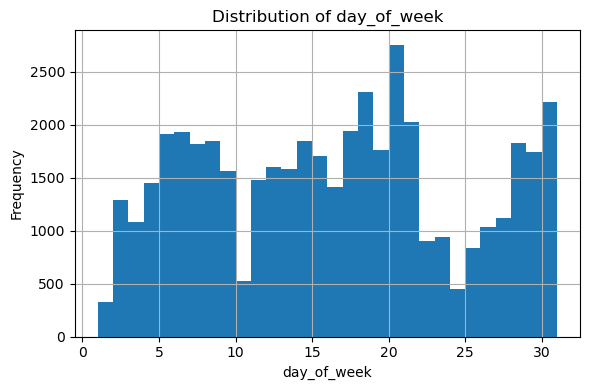

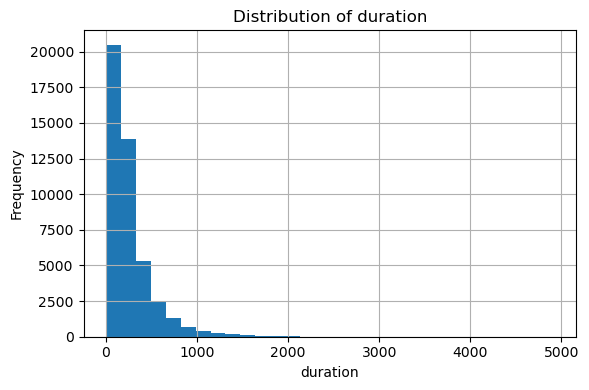

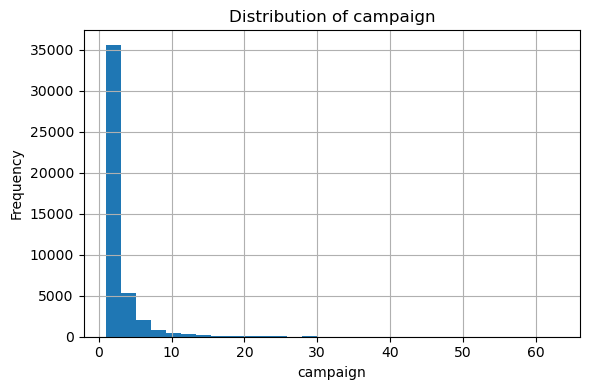

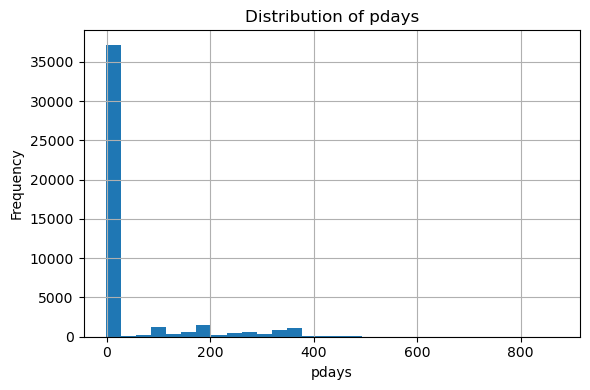

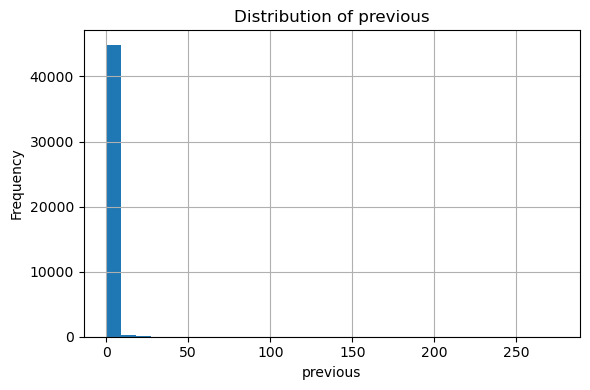

In [9]:
numeric_cols_eda = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in numeric_cols_eda:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## Exploratory analysis: subscription rate by categorical variables
This compares the percentage of customers subscribing across key categories. It is useful for business interpretation.


Subscription rate by job:


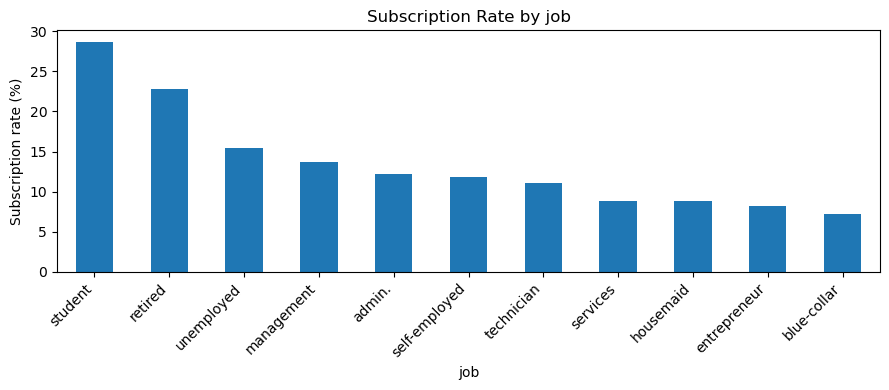

job
student          28.68
retired          22.79
unemployed       15.50
management       13.76
admin.           12.20
self-employed    11.84
technician       11.06
services          8.88
housemaid         8.79
entrepreneur      8.27
blue-collar       7.27
Name: y, dtype: float64


Subscription rate by marital:


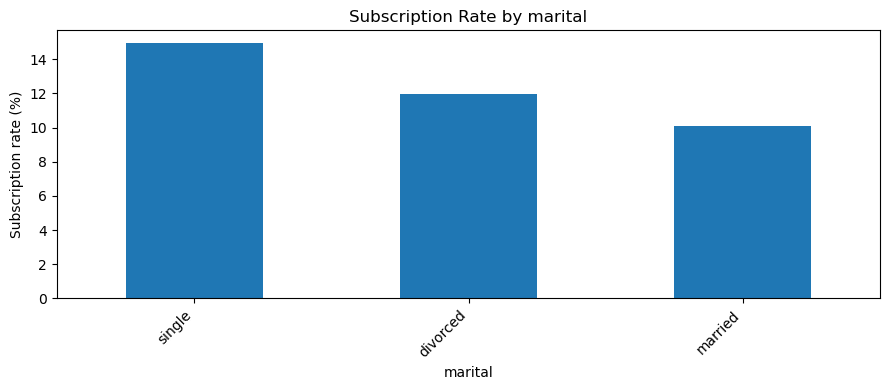

marital
single      14.95
divorced    11.95
married     10.12
Name: y, dtype: float64


Subscription rate by education:


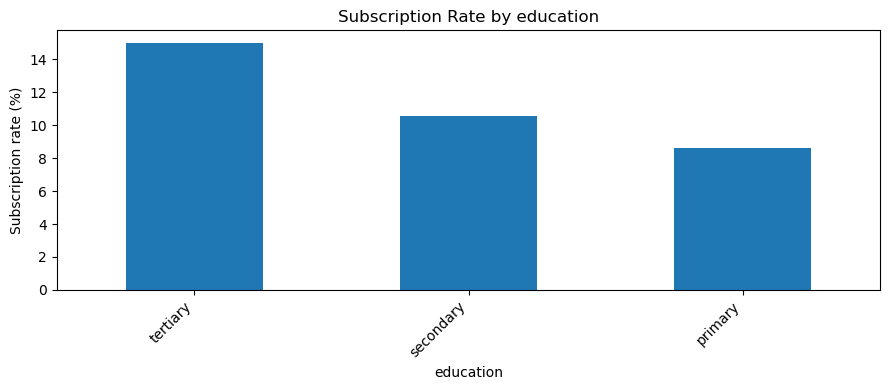

education
tertiary     15.01
secondary    10.56
primary       8.63
Name: y, dtype: float64


Subscription rate by housing:


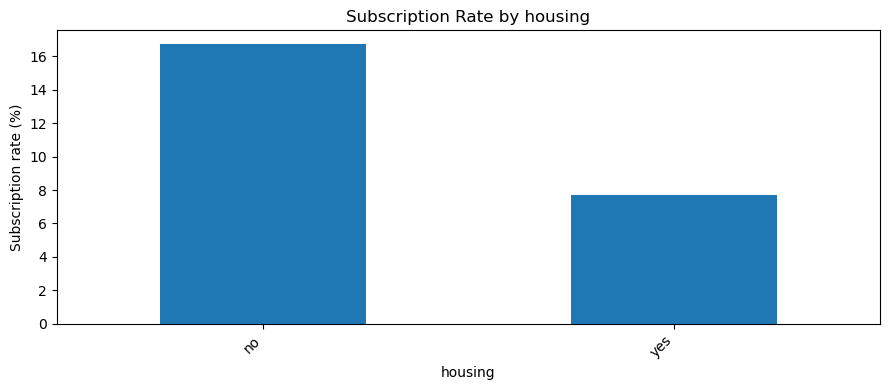

housing
no     16.7
yes     7.7
Name: y, dtype: float64


Subscription rate by loan:


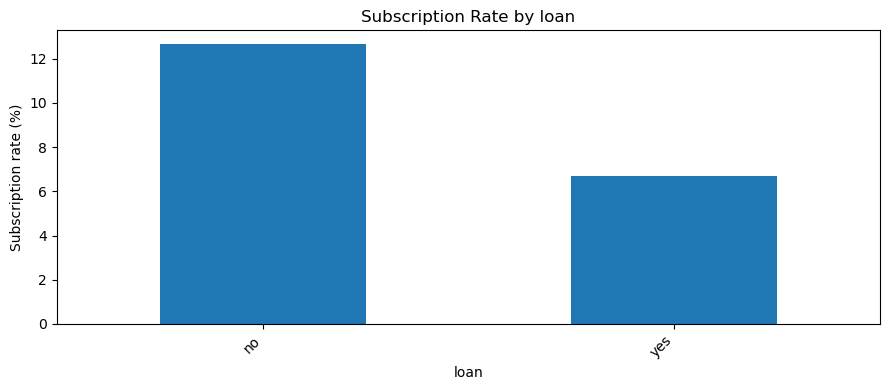

loan
no     12.66
yes     6.68
Name: y, dtype: float64


Subscription rate by contact:


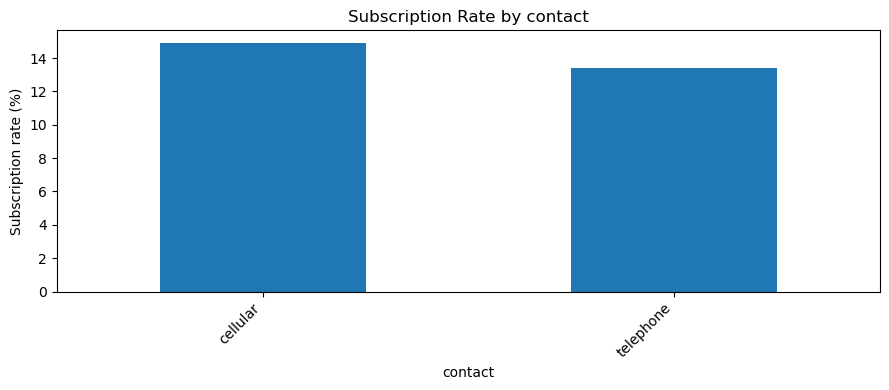

contact
cellular     14.92
telephone    13.42
Name: y, dtype: float64


Subscription rate by month:


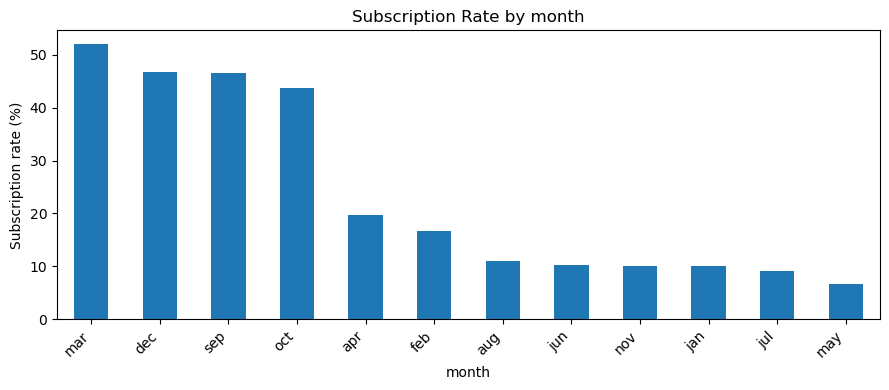

month
mar    51.99
dec    46.73
sep    46.46
oct    43.77
apr    19.68
feb    16.65
aug    11.01
jun    10.22
nov    10.15
jan    10.12
jul     9.09
may     6.72
Name: y, dtype: float64


Subscription rate by poutcome:


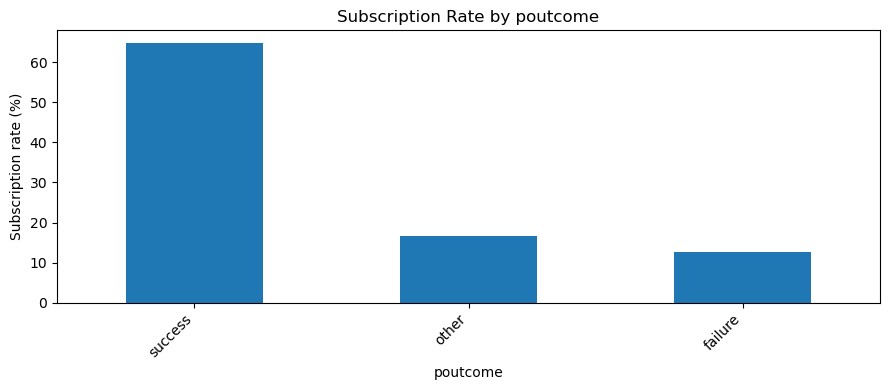

poutcome
success    64.73
other      16.68
failure    12.61
Name: y, dtype: float64

In [11]:
def plot_subscription_rate(column):
    rate = (
        df.groupby(column)["y"]
        .apply(lambda x: (x == "yes").mean() * 100)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(9, 4))
    rate.plot(kind="bar")
    plt.title(f"Subscription Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Subscription rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return rate.round(2)


for col in ["job", "marital", "education", "housing", "loan", "contact", "month", "poutcome"]:
    if col in df.columns:
        print(f"\nSubscription rate by {col}:")
        display(plot_subscription_rate(col))

## Correlation between numerical variables
Correlation helps identify relationships between numerical variables. It does not prove causation, but it is useful during exploration.

,age,balance,day_of_week,duration,campaign,pdays,previous
age,1.00,0.10,-0.01,-0.00,0.00,-0.02,0.00
balance,0.10,1.00,0.00,0.02,-0.01,0.00,0.02
day_of_week,-0.01,0.00,1.00,-0.03,0.16,-0.09,-0.05
duration,-0.00,0.02,-0.03,1.00,-0.08,-0.00,0.00
campaign,0.00,-0.01,0.16,-0.08,1.00,-0.09,-0.03
pdays,-0.02,0.00,-0.09,-0.00,-0.09,1.00,0.45
previous,0.00,0.02,-0.05,0.00,-0.03,0.45,1.00


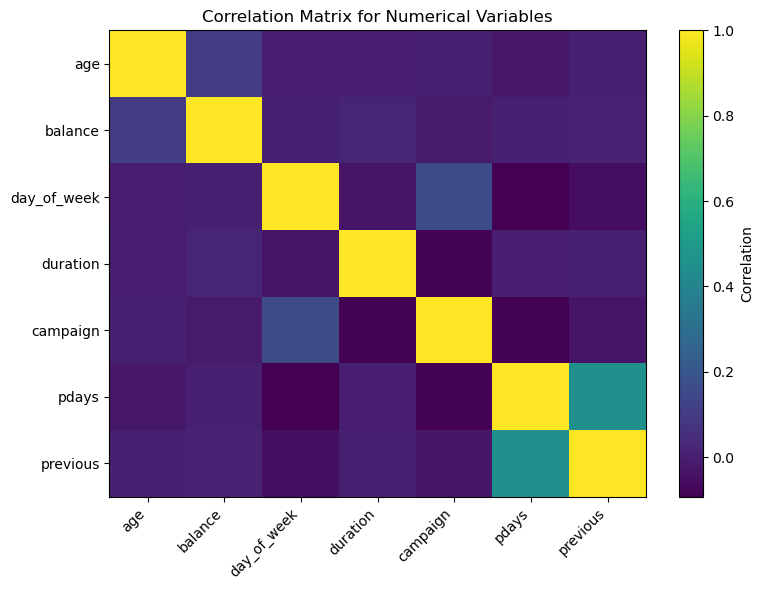

In [12]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()

display(corr.round(2))

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix for Numerical Variables")
plt.tight_layout()
plt.show()

##  Data preparation decision
For a realistic marketing targeting model, we remove `duration` from the model features.  

Reason: `duration` is only known after a phone call has happened. If the business wants to decide who to contact before calling, using `duration` would cause data leakage and make the model less realistic for campaign planning.

In [14]:
# Make a modelling copy of the dataset
model_df = df.copy()

# Treat 'unknown' as missing so it can be handled by the imputer
model_df = model_df.replace("unknown", np.nan)

# Convert target to binary: yes = 1, no = 0
model_df["target"] = model_df["y"].map({"yes": 1, "no": 0})

# Drop original target and duration to avoid leakage
features_to_drop = ["y", "target"]

if "duration" in model_df.columns:
    features_to_drop.append("duration")

X = model_df.drop(columns=features_to_drop)
y = model_df["target"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Target positive rate:", round(y.mean() * 100, 2), "%")

print("\nFeatures used:")
print(X.columns.tolist())

Feature matrix shape: (45211, 15)
Target vector shape: (45211,)
Target positive rate: 11.7 %

Features used:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'campaign', 'pdays', 'previous', 'poutcome']


## Train-test split
We use a stratified split so the training and testing sets keep a similar proportion of `yes` and `no` cases.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Training positive rate:", round(y_train.mean() * 100, 2), "%")
print("Testing positive rate:", round(y_test.mean() * 100, 2), "%")

Training set: (36168, 15)
Testing set: (9043, 15)
Training positive rate: 11.7 %
Testing positive rate: 11.7 %


## Preprocessing pipeline
The preprocessing pipeline does the following:

1. Imputes missing numerical values using the median.  
2. Scales numerical variables using standardisation.  
3. Imputes missing categorical values using the most frequent value.  
4. One-hot encodes categorical variables.

In [16]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

# Compatibility for different sklearn versions
try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

Numerical features: ['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## Define models for comparison
The assignment asks for comparison of multiple methods. This notebook compares three classification models:

1. Logistic Regression — simple and interpretable baseline.  
2. Decision Tree — interpretable non-linear model.  
3. Random Forest — stronger ensemble model that usually improves predictive performance.

In [17]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
}

pipelines = {
    name: Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

pipelines

{'Logistic Regression': Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['age', 'balance',
                                                    'day_of_week', 'campaign',
                                                    'pdays', 'previous']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   

## Train and evaluate all models
The key metrics are:

- **Accuracy:** overall correct predictions.  
- **Precision:** of predicted subscribers, how many actually subscribed.  
- **Recall:** of actual subscribers, how many the model found.  
- **F1-score:** balance between precision and recall.  
- **ROC-AUC:** ability to rank positive cases higher than negative cases.

In [18]:
results = []
fitted_models = {}

for name, pipe in pipelines.items():
    print(f"Training {name}...")
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df_rounded = results_df.copy()
for col in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    results_df_rounded[col] = results_df_rounded[col].round(4)

display(results_df_rounded)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...


,model,accuracy,precision,recall,f1,roc_auc
2,Random Forest,0.8383,0.3734,0.5633,0.4491,0.7895
0,Logistic Regression,0.7622,0.2681,0.5964,0.3699,0.7518
1,Decision Tree,0.6779,0.2145,0.6588,0.3237,0.7238


## Cross-validation check
Cross-validation gives a more stable estimate of performance than a single train-test split. Here, we use 3-fold stratified cross-validation with ROC-AUC.

In [19]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, pipe in pipelines.items():
    print(f"Cross-validating {name}...")
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results.append({
        "model": name,
        "mean_roc_auc": scores.mean(),
        "std_roc_auc": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="mean_roc_auc", ascending=False)
display(cv_results_df.round(4))

Cross-validating Logistic Regression...
Cross-validating Decision Tree...
Cross-validating Random Forest...


,model,mean_roc_auc,std_roc_auc
2,Random Forest,0.7770,0.0027
0,Logistic Regression,0.7476,0.0033
1,Decision Tree,0.7208,0.0064


## Confusion matrices
Confusion matrices show true positives, true negatives, false positives, and false negatives.

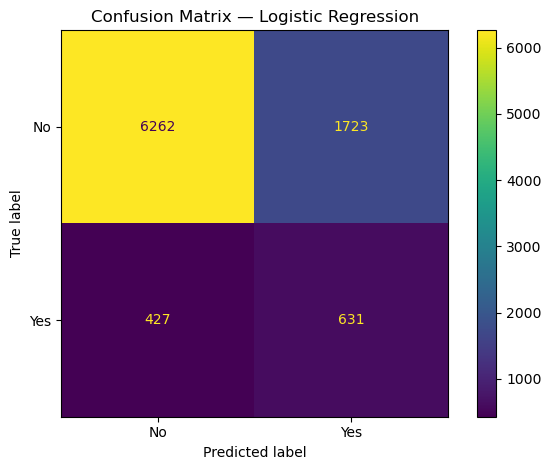

Classification report — Logistic Regression
              precision    recall  f1-score   support

          No       0.94      0.78      0.85      7985
         Yes       0.27      0.60      0.37      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.69      0.61      9043
weighted avg       0.86      0.76      0.80      9043



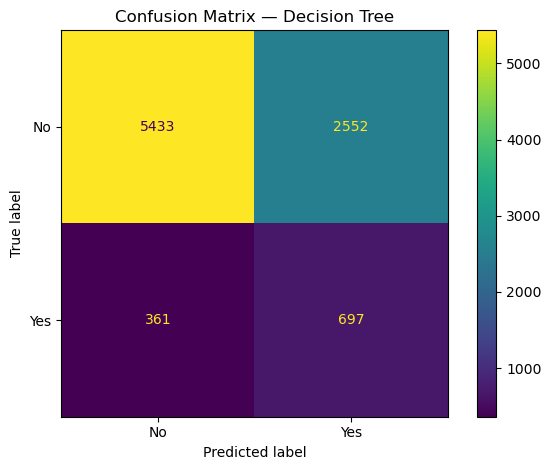

Classification report — Decision Tree
              precision    recall  f1-score   support

          No       0.94      0.68      0.79      7985
         Yes       0.21      0.66      0.32      1058

    accuracy                           0.68      9043
   macro avg       0.58      0.67      0.56      9043
weighted avg       0.85      0.68      0.73      9043



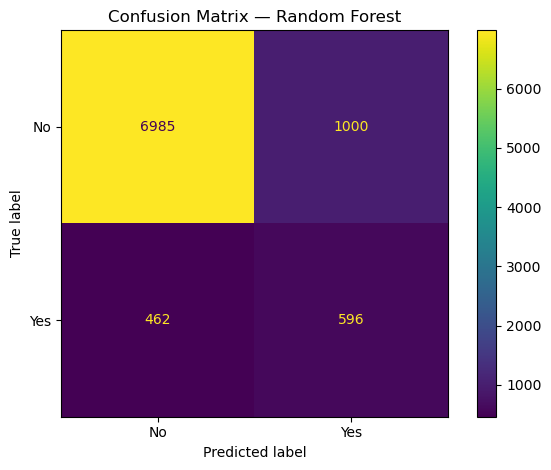

Classification report — Random Forest
              precision    recall  f1-score   support

          No       0.94      0.87      0.91      7985
         Yes       0.37      0.56      0.45      1058

    accuracy                           0.84      9043
   macro avg       0.66      0.72      0.68      9043
weighted avg       0.87      0.84      0.85      9043



In [20]:
for name, pipe in fitted_models.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

    print(f"Classification report — {name}")
    print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

## ROC curves
ROC curves compare the ranking ability of the models across different thresholds.

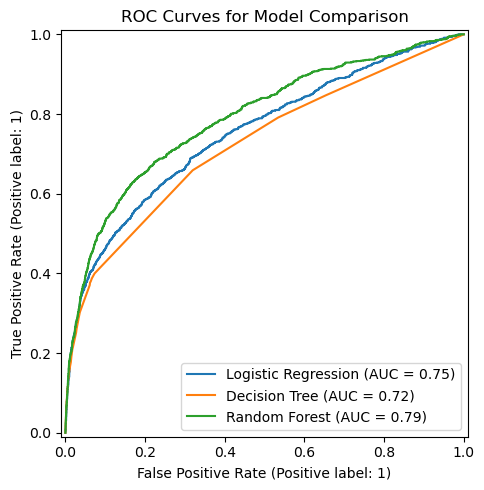

In [21]:
plt.figure(figsize=(7, 5))
for name, pipe in fitted_models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=plt.gca())

plt.title("ROC Curves for Model Comparison")
plt.tight_layout()
plt.show()

## Select the best model
This cell selects the model with the highest F1-score. F1 is suitable here because the positive class is relatively small and the business cares about identifying likely subscribers.

In [22]:
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

print("Best model based on F1-score:", best_model_name)
display(results_df_rounded[results_df_rounded["model"] == best_model_name])

Best model based on F1-score: Random Forest


,model,accuracy,precision,recall,f1,roc_auc
2,Random Forest,0.8383,0.3734,0.5633,0.4491,0.7895


## Feature importance / model interpretation
This extracts feature importance for tree-based models or coefficients for logistic regression.

,feature,importance
0,num__age,0.107164
1,num__balance,0.104312
45,cat__poutcome_success,0.089877
2,num__day_of_week,0.080181
4,num__pdays,0.073911
43,cat__poutcome_failure,0.061408
25,cat__housing_no,0.047245
26,cat__housing_yes,0.045311
3,num__campaign,0.044319
5,num__previous,0.037855


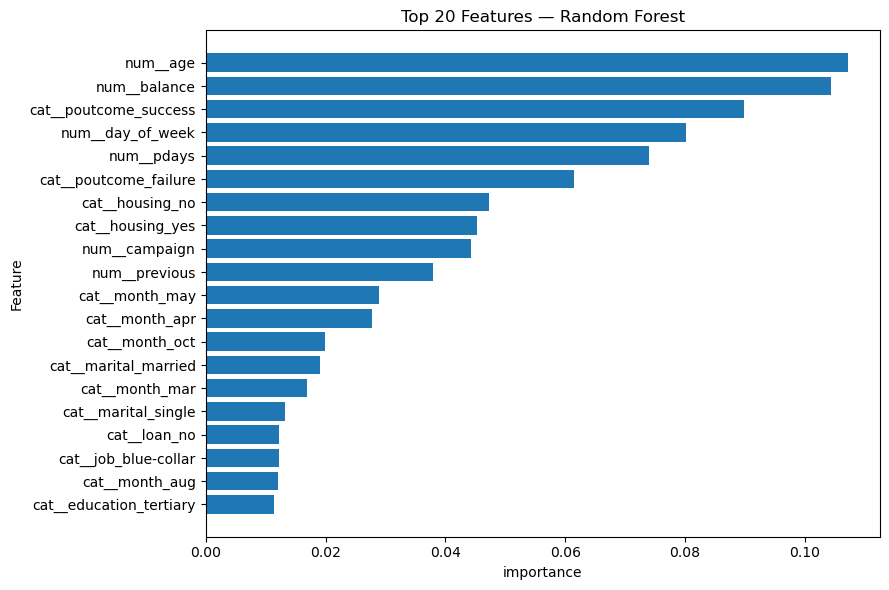

In [23]:
def get_feature_names_from_pipeline(pipe):
    preprocess_step = pipe.named_steps["preprocess"]
    return preprocess_step.get_feature_names_out()

def get_importance_table(pipe):
    feature_names = get_feature_names_from_pipeline(pipe)
    model = pipe.named_steps["model"]

    if hasattr(model, "feature_importances_"):
        importance_values = model.feature_importances_
        importance_type = "importance"
    elif hasattr(model, "coef_"):
        importance_values = model.coef_[0]
        importance_type = "coefficient"
    else:
        raise ValueError("This model does not expose feature importances or coefficients.")

    importance_df = pd.DataFrame({
        "feature": feature_names,
        importance_type: importance_values
    })

    if importance_type == "coefficient":
        importance_df["absolute_coefficient"] = importance_df[importance_type].abs()
        importance_df = importance_df.sort_values("absolute_coefficient", ascending=False)
    else:
        importance_df = importance_df.sort_values(importance_type, ascending=False)

    return importance_df, importance_type

importance_df, importance_type = get_importance_table(best_model)

top_importance = importance_df.head(20)
display(top_importance)

plt.figure(figsize=(9, 6))
plot_df = top_importance.sort_values(by=importance_type, ascending=True)
plt.barh(plot_df["feature"], plot_df[importance_type])
plt.title(f"Top 20 Features — {best_model_name}")
plt.xlabel(importance_type)
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Probability-based customer targeting analysis
This converts model predictions into a business decision: focus on the top-scored customers first.

,customers,actual_subscribers,subscription_rate,avg_predicted_probability
probability_decile,,,,
10,905,447,49.39,78.46
9,904,185,20.46,54.63
8,904,99,10.95,43.70
7,904,76,8.41,38.50
6,904,67,7.41,34.67
5,905,51,5.64,31.57
4,904,42,4.65,28.55
3,904,28,3.10,25.45
2,904,39,4.31,22.12


Overall test subscription rate: 11.70%
Top decile subscription rate: 49.39%
Lift in top decile compared with average: 4.22x


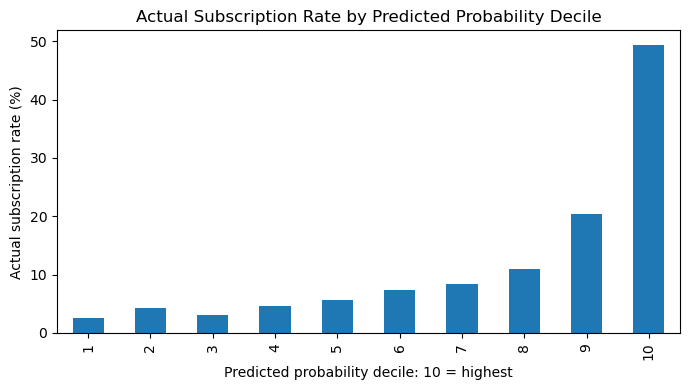

In [24]:
# Predicted probability for each customer in the test set
proba = best_model.predict_proba(X_test)[:, 1]

targeting_df = X_test.copy()
targeting_df["actual_subscribed"] = y_test.values
targeting_df["predicted_probability"] = proba

# Create deciles: 10 = highest predicted probability, 1 = lowest
# duplicates='drop' avoids issues if probabilities contain many ties
targeting_df["probability_decile"] = pd.qcut(
    targeting_df["predicted_probability"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

decile_summary = (
    targeting_df.groupby("probability_decile")
    .agg(
        customers=("actual_subscribed", "size"),
        actual_subscribers=("actual_subscribed", "sum"),
        subscription_rate=("actual_subscribed", "mean"),
        avg_predicted_probability=("predicted_probability", "mean")
    )
    .sort_index(ascending=False)
)

decile_summary["subscription_rate"] = (decile_summary["subscription_rate"] * 100).round(2)
decile_summary["avg_predicted_probability"] = (decile_summary["avg_predicted_probability"] * 100).round(2)

display(decile_summary)

overall_rate = y_test.mean() * 100
top_decile_rate = decile_summary.iloc[0]["subscription_rate"]
lift = top_decile_rate / overall_rate

print(f"Overall test subscription rate: {overall_rate:.2f}%")
print(f"Top decile subscription rate: {top_decile_rate:.2f}%")
print(f"Lift in top decile compared with average: {lift:.2f}x")

plt.figure(figsize=(7, 4))
decile_summary.sort_index()["subscription_rate"].plot(kind="bar")
plt.title("Actual Subscription Rate by Predicted Probability Decile")
plt.xlabel("Predicted probability decile: 10 = highest")
plt.ylabel("Actual subscription rate (%)")
plt.tight_layout()
plt.show()

##  Segment-level recommendations
This identifies groups with higher observed subscription rates. A minimum group size is used to avoid overinterpreting very small categories.

In [26]:
def segment_table(data, column, min_count=100):
    summary = (
        data.groupby(column)
        .agg(
            customers=("y", "size"),
            subscribers=("y", lambda x: (x == "yes").sum()),
            subscription_rate=("y", lambda x: (x == "yes").mean() * 100)
        )
        .query("customers >= @min_count")
        .sort_values("subscription_rate", ascending=False)
    )
    return summary.round(2)


segment_columns = ["job", "marital", "education", "housing", "loan", "contact", "month", "poutcome"]

for col in segment_columns:
    if col in df.columns:
        print(f"\nTop segments by subscription rate: {col}")
        display(segment_table(df, col).head(10))


Top segments by subscription rate: job


,customers,subscribers,subscription_rate
job,,,
student,938,269,28.68
retired,2264,516,22.79
unemployed,1303,202,15.50
management,9458,1301,13.76
admin.,5171,631,12.20
self-employed,1579,187,11.84
technician,7597,840,11.06
services,4154,369,8.88
housemaid,1240,109,8.79



Top segments by subscription rate: marital


,customers,subscribers,subscription_rate
marital,,,
single,12790,1912,14.95
divorced,5207,622,11.95
married,27214,2755,10.12



Top segments by subscription rate: education


...

,customers,subscribers,subscription_rate
contact,,,
cellular,29285,4369,14.92
telephone,2906,390,13.42



Top segments by subscription rate: month


,customers,subscribers,subscription_rate
month,,,
mar,477,248,51.99
dec,214,100,46.73
sep,579,269,46.46
oct,738,323,43.77
apr,2932,577,19.68
feb,2649,441,16.65
aug,6247,688,11.01
jun,5341,546,10.22
nov,3970,403,10.15



Top segments by subscription rate: poutcome


,customers,subscribers,subscription_rate
poutcome,,,
success,1511,978,64.73
other,1840,307,16.68
failure,4901,618,12.61


## Save outputs for the report appendix
This saves model results, feature importance, and the best trained model.

In [27]:
results_df_rounded.to_csv("model_comparison_results.csv", index=False)
cv_results_df.round(4).to_csv("cross_validation_results.csv", index=False)
importance_df.to_csv("feature_importance_or_coefficients.csv", index=False)
joblib.dump(best_model, "best_bank_marketing_model.pkl")

print("Saved files:")
print("- model_comparison_results.csv")
print("- cross_validation_results.csv")
print("- feature_importance_or_coefficients.csv")
print("- best_bank_marketing_model.pkl")

Saved files:
- model_comparison_results.csv
- cross_validation_results.csv
- feature_importance_or_coefficients.csv
- best_bank_marketing_model.pkl


## Test a new customer prediction
This cell shows how the trained model could be used for a new customer record. Adjust the values to test different customer profiles.

In [28]:
# Build one sample customer using the same columns as X
new_customer = pd.DataFrame([{
    col: X[col].mode(dropna=True)[0] if X[col].dtype == "object" else X[col].median()
    for col in X.columns
}])

# Example custom changes
if "age" in new_customer.columns:
    new_customer.loc[0, "age"] = 35
if "job" in new_customer.columns:
    new_customer.loc[0, "job"] = "management"
if "marital" in new_customer.columns:
    new_customer.loc[0, "marital"] = "single"
if "education" in new_customer.columns:
    new_customer.loc[0, "education"] = "tertiary"
if "housing" in new_customer.columns:
    new_customer.loc[0, "housing"] = "no"
if "loan" in new_customer.columns:
    new_customer.loc[0, "loan"] = "no"

predicted_probability = best_model.predict_proba(new_customer)[:, 1][0]
predicted_class = best_model.predict(new_customer)[0]

print("New customer record:")
display(new_customer)
print(f"Predicted probability of subscription: {predicted_probability:.2%}")
print("Predicted class:", "yes" if predicted_class == 1 else "no")

New customer record:


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,campaign,pdays,previous,poutcome
0,35.0,management,single,tertiary,no,448.0,no,no,cellular,16.0,may,2.0,-1.0,0.0,failure


Predicted probability of subscription: 54.45%
Predicted class: yes


## Implementation summary for the report
Use this as notes when writing the Modelling, Prediction, and Recommendations section.

In [30]:
print("IMPLEMENTATION SUMMARY")
print("----------------------")
print(f"Dataset rows and columns: {df.shape}")
print(f"Features used for modelling: {X.shape[1]}")
print("Target variable: y converted to binary target where yes=1 and no=0")
print("Duration removed from features to avoid data leakage for pre-call targeting.")
print(f"Train/test split: {X_train.shape[0]} training rows and {X_test.shape[0]} testing rows")
print(f"Models compared: {', '.join(models.keys())}")
print(f"Best model based on F1-score: {best_model_name}")

print("\nModel comparison:")
print(results_df_rounded.to_string(index=False))

IMPLEMENTATION SUMMARY
----------------------
Dataset rows and columns: (45211, 17)
Features used for modelling: 15
Target variable: y converted to binary target where yes=1 and no=0
Duration removed from features to avoid data leakage for pre-call targeting.
Train/test split: 36168 training rows and 9043 testing rows
Models compared: Logistic Regression, Decision Tree, Random Forest
Best model based on F1-score: Random Forest

Model comparison:
              model  accuracy  precision  recall     f1  roc_auc
      Random Forest    0.8383     0.3734  0.5633 0.4491   0.7895
Logistic Regression    0.7622     0.2681  0.5964 0.3699   0.7518
      Decision Tree    0.6779     0.2145  0.6588 0.3237   0.7238
